# MVP da Disciplina: Sprint: Qualidade de Software, Segurança e Sistemas Inteligentes (40530010063_20260_01) - Pós-graduação de Engenharia de Software da PUC-Rio

O MVP em questão se tratará de um sistema inteligente com base em um modelo preditivo gerado a partir do dataset "E-Commerce Behavior Dataset (8000 Users)" escolhido no Kaggle.

--> Link para o dataset, acessado pela última vez em (06/04/2026): https://www.kaggle.com/datasets/asifxzaman/e-commerce-behavior-dataset8000-users

O Dataset foi escolhido com a premissa de gerar um modelo preditivo voltado para determinar se uma compra será feita ou não por um usuário.

# Detalhamento do Dataset:

O Dataset possui as seguintes colunas, seguindas dos seguintes detalhamentos a respeito de cada uma:
1. user_id: Unique identifier for each user
      * Identificador único para cada usuário
2. age: Age of the user (years)
      * Idade do usuário (anos)
3. gender: Gender of the user (Male/Female)
      * Gênero do usuário (Homem/Mulher)
4. device_type: Device used to access the platform (Mobile/Desktop/Tablet)
      * Aparelho utilizado para acessar a plataforma (Celular/Gabinete/Tablet)
5. time_on_site: Total time spent on the website (minutes)
      * Tempo total gasto no website (minutos)
6. pages_viewed: Number of pages viewed during the session
      * Número de páginas vistas durante a sessão
7. previous_purchases: Total number of past purchases made by the user
      * Número total de compras passadas feitas pelo usuário
8. cart_items: Number of items added to the cart
      * Número de itens adicionado ao carrinho de compras
9. discount_seen: Whether the user was shown a discount (0 = No, 1 = Yes)
      * Se foi apresentado um desconto ao usuário (0 = Não, 1 = Sim)
10. ad_clicked: Whether the user clicked on an advertisement (0 = No, 1 = Yes)
      * Se o usuário clicou ou não em um anúncio (0 = Não, 1 = Sim)
11. returning_user: Whether the user is a returning customer (0 = No, 1 = Yes)
      * Se o usuário é ou não um cliente recorrente (0 = Não, 1 = Sim)
12. avg_session_time: Average time spent per session (minutes)
      * Tempo médio gasto por sessão (minutos)
13. bounce_rate: Percentage of sessions where the user left immediately (0–100)
      * Percentagem de sessões onde o usuário saiu imediatamente (0-100)
14. purchase: Target variable indicating whether the user made a purchase (0 = No, 1 = Yes)
      * Variavel alvo indicando se o usuário realizou a compra ou não


Considerando todas as variáveis podem ser feitas ponderações sobre algumas, no caso selecionar quais serão utilizadas como 'feature' para a modelagem do sistema, quais não devem entrar no modelo e quais são problematicas e por isso serão removidas.

## Variáveis que não devem ser inseridas no modelo
 - user_id é apenas uma variável técnica, não deve ser levada para o modelo
 - purchase é a variável alvo, então não deve ser levada como feature.

## Variáveis que podem atrapalhar a aplicação e devem ser removidas do modelo
 - time_on_site é uma variável que existe apenas após a sessão de um usuário, para fazer valer em uma aplicação, provavelmente teria de ser usado uma simulação de tempo e pode acabar causando _data leakage_
 - avg_session_time é uma estatística histórica, onde usuários novos não teriam essa variável e não faria sentido realizar um _input_ manual dela.
 - bounce_rate é uma variável que faria mais sentido em uma análise do que ao tentar realizar uma inferência, para uma única predição individual não parece fazer muito sentido
 - pages_viewed é uma variável similar ao time_on_site, considerando que depende da navegação já ter ocorrido, clientes novos provavelmente não teriam essa variável.

 ## Variáveis que se encaixam no escopo desse projeto
 As variáveis então que permitem um _input_ simples e boa previsibilidade seriam as seguintes:
 - age
 - gender
 - device_type
 - previous_purchases
 - returning_user
 - discount_seen
 - ad_clicked
 - cart_items

 Então será criado um subdataset apenas com essas 8 _features_, uma vez que apenas essas estariam disponíveis no momento da predição em um ambiente real de aplicação, evitando o uso de atributos dependentes de navegação histórica ou métricas agregadas.

# Imports para execução do gerador de modelo

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC



# Carga do Dataset

In [2]:
url = "https://raw.githubusercontent.com/sergio-mpm/api-fullstack-compra-inteligente/refs/heads/main/ecommerce_user_behavior_8000.csv"
dataset = pd.read_csv(url, delimiter=',')

print(f"{'='*90}\nDataset carregado\nLinhas: {dataset.shape[0]}\nColunas: {dataset.shape[1]}\n{'='*90}\n")

dataset.head(10)

for index, coluna in enumerate(dataset.columns):
  print(f"{index}: {coluna}")

Dataset carregado
Linhas: 8000
Colunas: 14

0: user_id
1: age
2: gender
3: device_type
4: time_on_site
5: pages_viewed
6: previous_purchases
7: cart_items
8: discount_seen
9: ad_clicked
10: returning_user
11: avg_session_time
12: bounce_rate
13: purchase


# Criação do subdataset contendo apenas as colunas selecionadas para o problema

In [3]:
features = [
    "age",
    "gender",
    "device_type",
    "previous_purchases",
    "cart_items",
    "discount_seen",
    "ad_clicked",
    "returning_user"
]

dataset_select = dataset[features + ["purchase"]]

print(f"Linhas do novo dataset: {dataset_select.shape[0]}\n")
print(f"Colunas do novo dataset: {dataset_select.shape[1]}\n")
print(f"Colunas do novo dataset:\n{dataset_select.columns.tolist()}")

Linhas do novo dataset: 8000

Colunas do novo dataset: 9

Colunas do novo dataset:
['age', 'gender', 'device_type', 'previous_purchases', 'cart_items', 'discount_seen', 'ad_clicked', 'returning_user', 'purchase']


# Observação:

Com o novo dataset gerado a partir do dataset original, transferindo os valores que interessam e que serão úteis para o projeto, pode-se iniciar a exploração dos dados

# Exploração incial dos dados

Só existem essa quantidade de aparelhos: 3


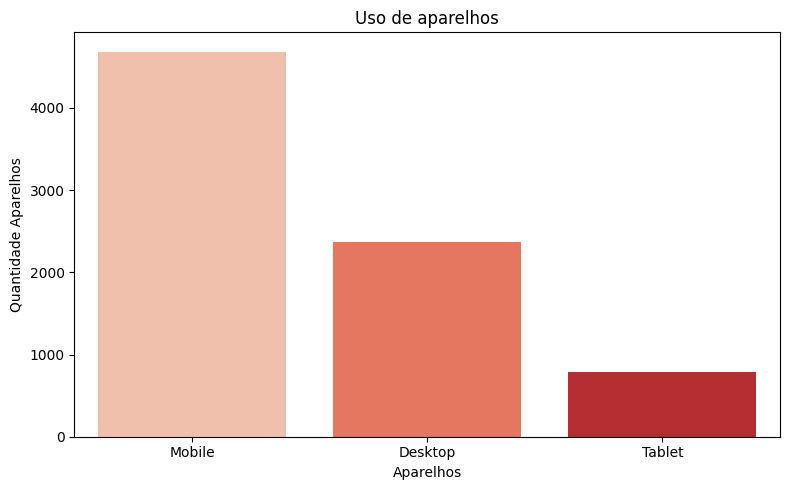

In [4]:
# Aqui está sendo verificado qual aparelho está sendo mais utilizados
dataset_eda = dataset_select.dropna(subset=['device_type'])

# Confirmamos que existe apenas 3 aparelhos (Mobile/Desktop/Tablet)
print(f"Só existem essa quantidade de aparelhos: {dataset_select['device_type'].nunique()}")

ordem_device = ['Mobile','Desktop','Tablet']
plt.figure(figsize=(8,5))
sns.countplot(data=dataset_eda, x='device_type', order=ordem_device, palette='Reds')
plt.title('Uso de aparelhos')
plt.xlabel('Aparelhos')
plt.ylabel('Quantidade Aparelhos')
plt.tight_layout()
plt.show()

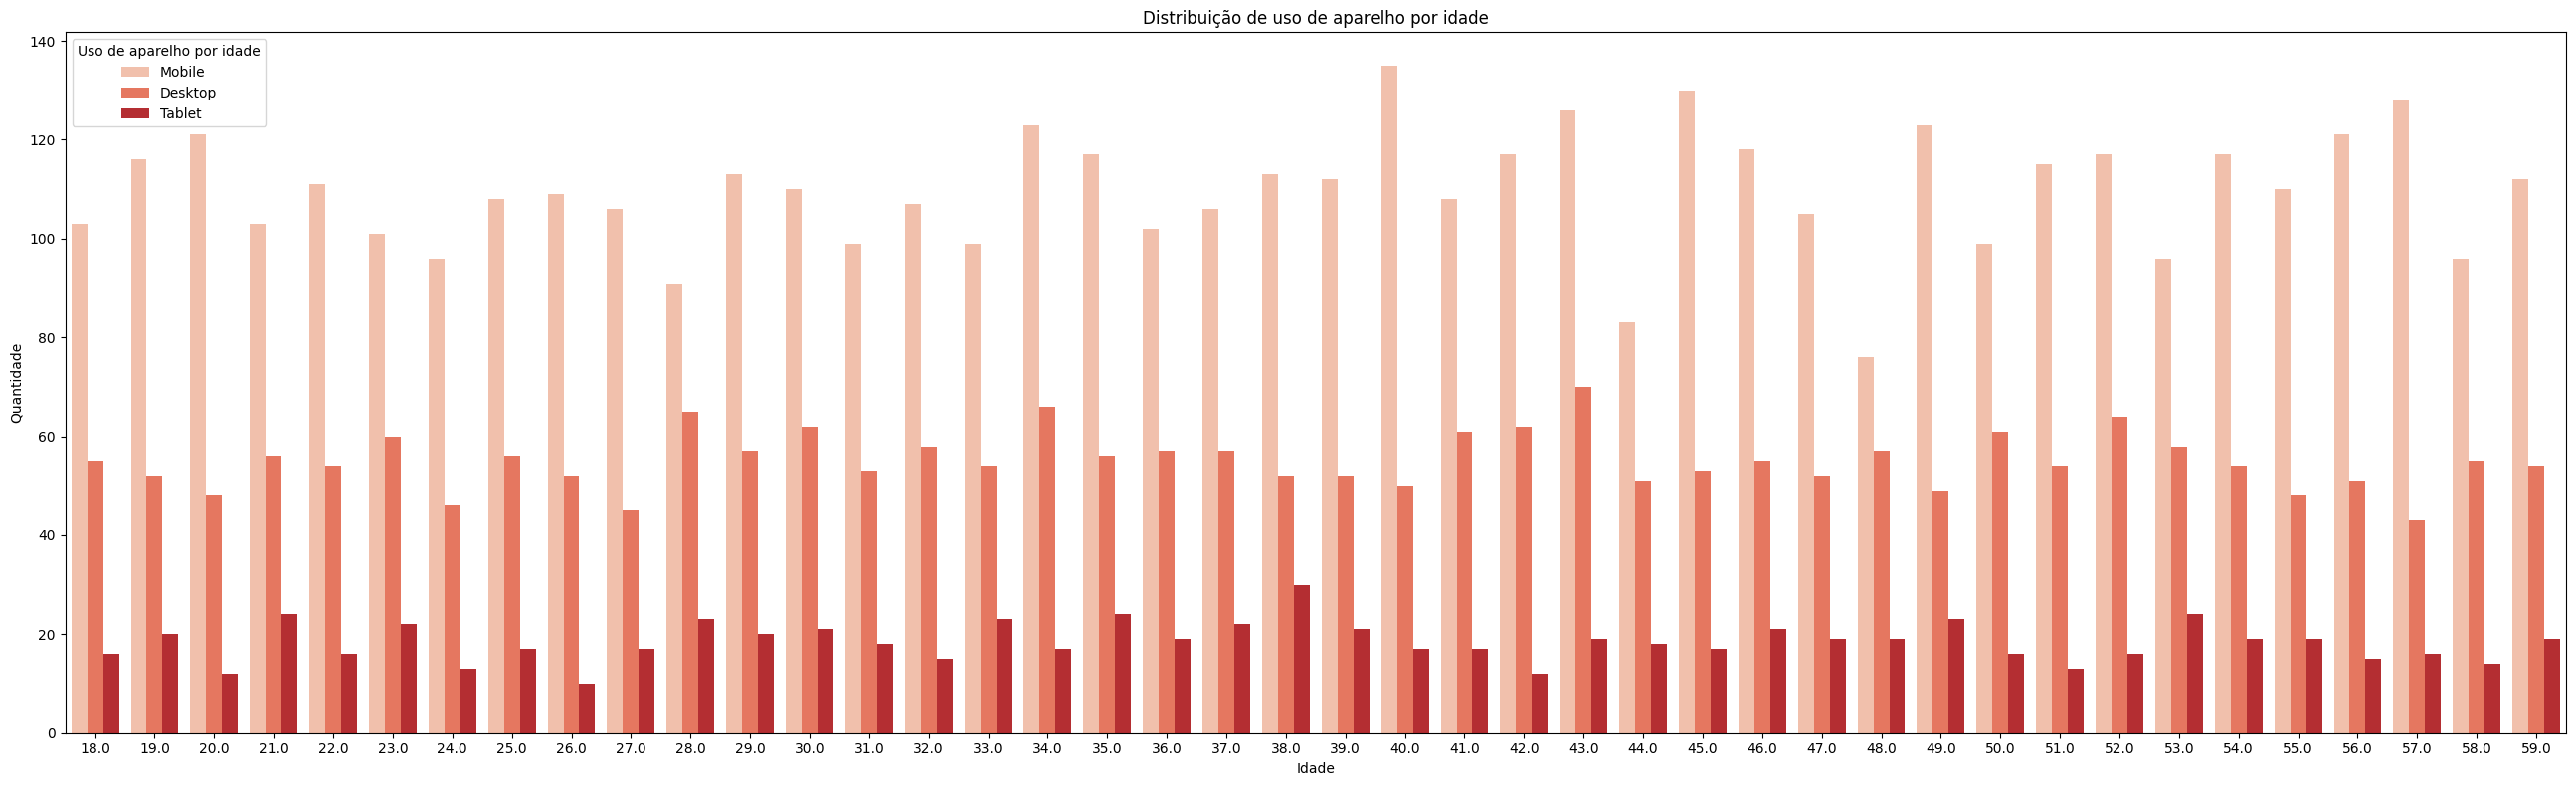

In [5]:
# Aqui será observado a distribuição por idade do uso dos aparelhos
dataset_eda = dataset_eda.dropna(subset=['age'])
plt.figure(figsize=(26,8))
sns.countplot(data=dataset_eda, x='age', hue='device_type', hue_order=ordem_device, palette='Reds')
plt.title('Distribuição de uso de aparelho por idade')
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.legend(title='Uso de aparelho por idade')
plt.tight_layout()
plt.show()


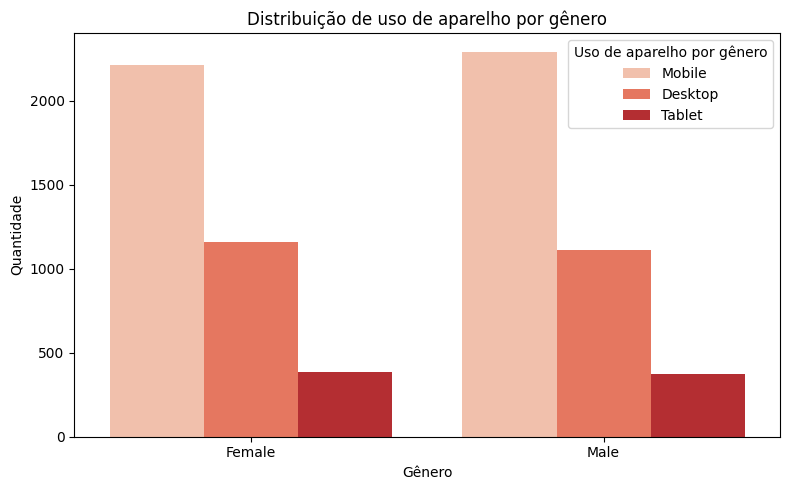

In [6]:
# Aqui será observada a distribuição do uso de aparelho por gênero
dataset_eda = dataset_eda.dropna(subset=['gender'])
plt.figure(figsize=(8,5))
sns.countplot(data=dataset_eda, x='gender', hue='device_type', hue_order=ordem_device, palette='Reds')
plt.title('Distribuição de uso de aparelho por gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.legend(title='Uso de aparelho por gênero')
plt.tight_layout()
plt.show()

# Observação a respeito da exploração dos dados
Utilizou-se das _features_ dentro do dataset criado para poder avaliar a qualidade dos dados, como eles podem estar relacionados entre si e quais observações podem ser feitas a respeito dos dados.

Pensando no uso desses dados voltados para um modelo de classificação, onde pode-se prever a probabilidade de compra baseado nesse conjunto de dados, a meta será criar esse modelo utilizando os métodos apreciados na disciplina.

# Instância inicial do dataset para modelagem

In [7]:

test_size = 0.20
seed = 7

X = dataset_select[features]
Y = dataset_select["purchase"]

dataset_select["purchase"].isna().sum()
dataset_select["purchase"].value_counts(dropna=False)
dataset_select = dataset_select.dropna(subset=["purchase"])

# tratando valores NaN
X = dataset_select.drop(columns=["purchase"])
Y = dataset_select["purchase"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)
pipeline_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=seed))
])
pipeline_knn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])
pipeline_nb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])
pipeline_cart = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier())
])

X_train, X_test, Y_train, Y_test = train_test_split(X,
                                                    Y,
                                                    test_size=test_size,
                                                    shuffle=True,
                                                    random_state=seed,
                                                    stratify=Y)

scoring = 'roc_auc'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

# Observação a cerca da importação dos dados

Durante a análise do dataset, foi identificado que a variável alvo (purchase) continha valores ausentes. Como não é possível inferir a classe de saída em um problema de classificação supervisionada, as instâncias sem rótulo foram removidas do conjunto de dados, mantendo-se apenas os registros válidos.

Durante os estudos realizados, inicialmente utilizando "scoring = 'accuracy'", foi detectado que o modelo não conseguia separar compradores de não compradores, então passou-se a utilizar "scoring = 'roc_auc'" com intuito de identificar se o modelo conseguia fazer essa distinção.

# Criação e avaliação de modelos: Linha Base

KNN: 0.5467 (0.1495)
CART: 0.4993 (0.0004)
NB: 0.8396 (0.2689)
SVM: 0.9005 (0.0874)


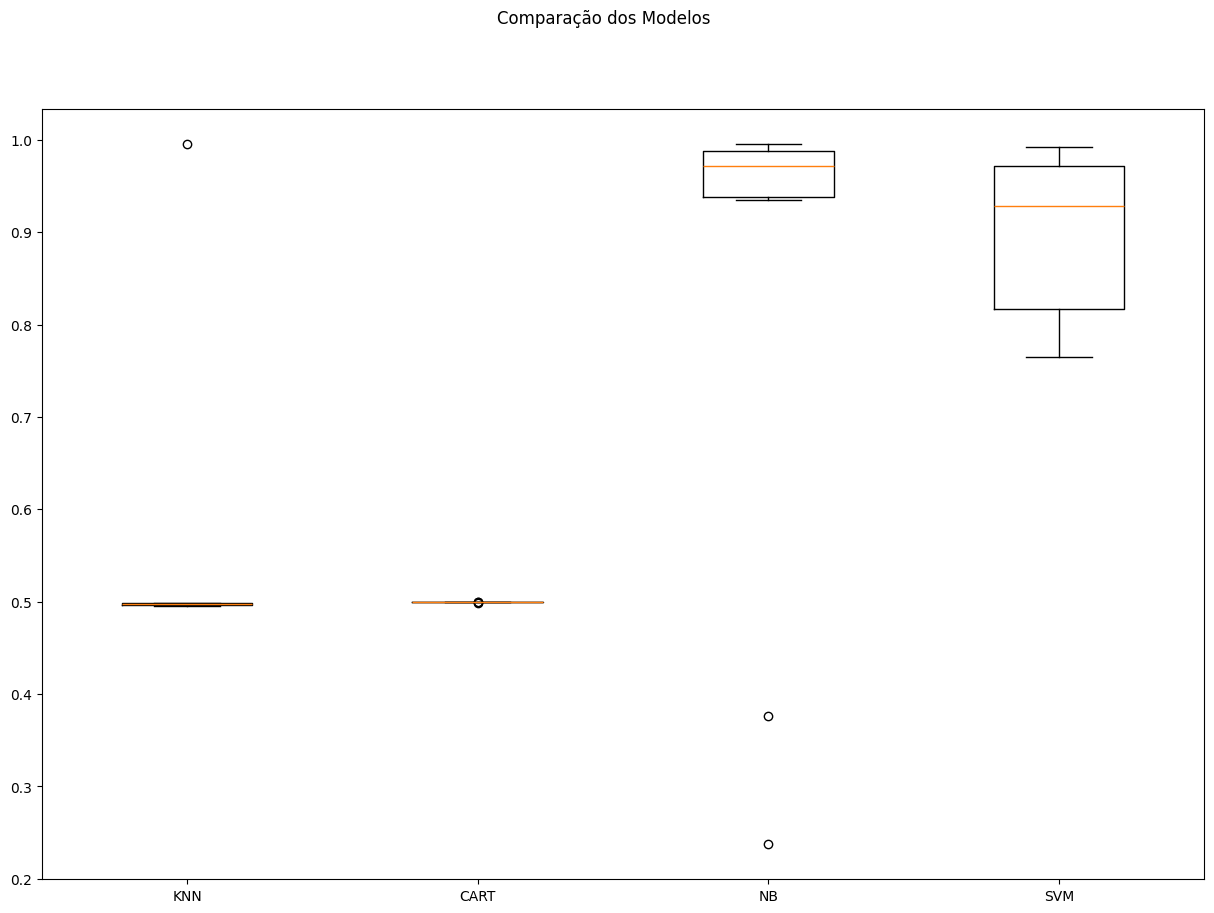

In [8]:
np.random.seed(7)

models = []
models.append(('KNN', pipeline_knn))
models.append(('CART', pipeline_cart))
models.append(('NB', pipeline_nb))
models.append(('SVM', pipeline_svm))

results = []
names = []

for name, model in models:
    cv_results = cross_val_score(model,
                                 X_train,
                                 Y_train,
                                 cv=kfold,
                                 scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})"
    print(msg)

fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# Observação a respeito da modelagem

Durante a etapa de modelagem, foi identificado que o conjunto de dados continha variáveis categóricas, como gênero do usuário. Como os algoritmos de machine learning utilizados exigem entradas numéricas, foi aplicado o processo de codificação One-Hot Encoding. Todo o pré-processamento, incluindo imputação de valores ausentes, padronização de atributos numéricos e codificação de variáveis categóricas, foi integrado aos pipelines de treinamento, evitando vazamento de dados e garantindo a correta validação cruzada

# Criação e avaliação de modelos: Dados Padronizados e Normalizados

KNN-orig: 0.496 (0.002)
CART-orig: 0.499 (0.000)
NB-orig: 0.841 (0.265)
SVM-orig: 0.730 (0.131)
KNN-padr: 0.547 (0.149)
CART-padr: 0.499 (0.001)
NB-padr: 0.840 (0.269)
SVM-padr: 0.900 (0.087)
KNN-norm: 0.546 (0.150)
CART-norm: 0.499 (0.000)
NB-norm: 0.839 (0.271)
SVM-norm: 0.881 (0.113)


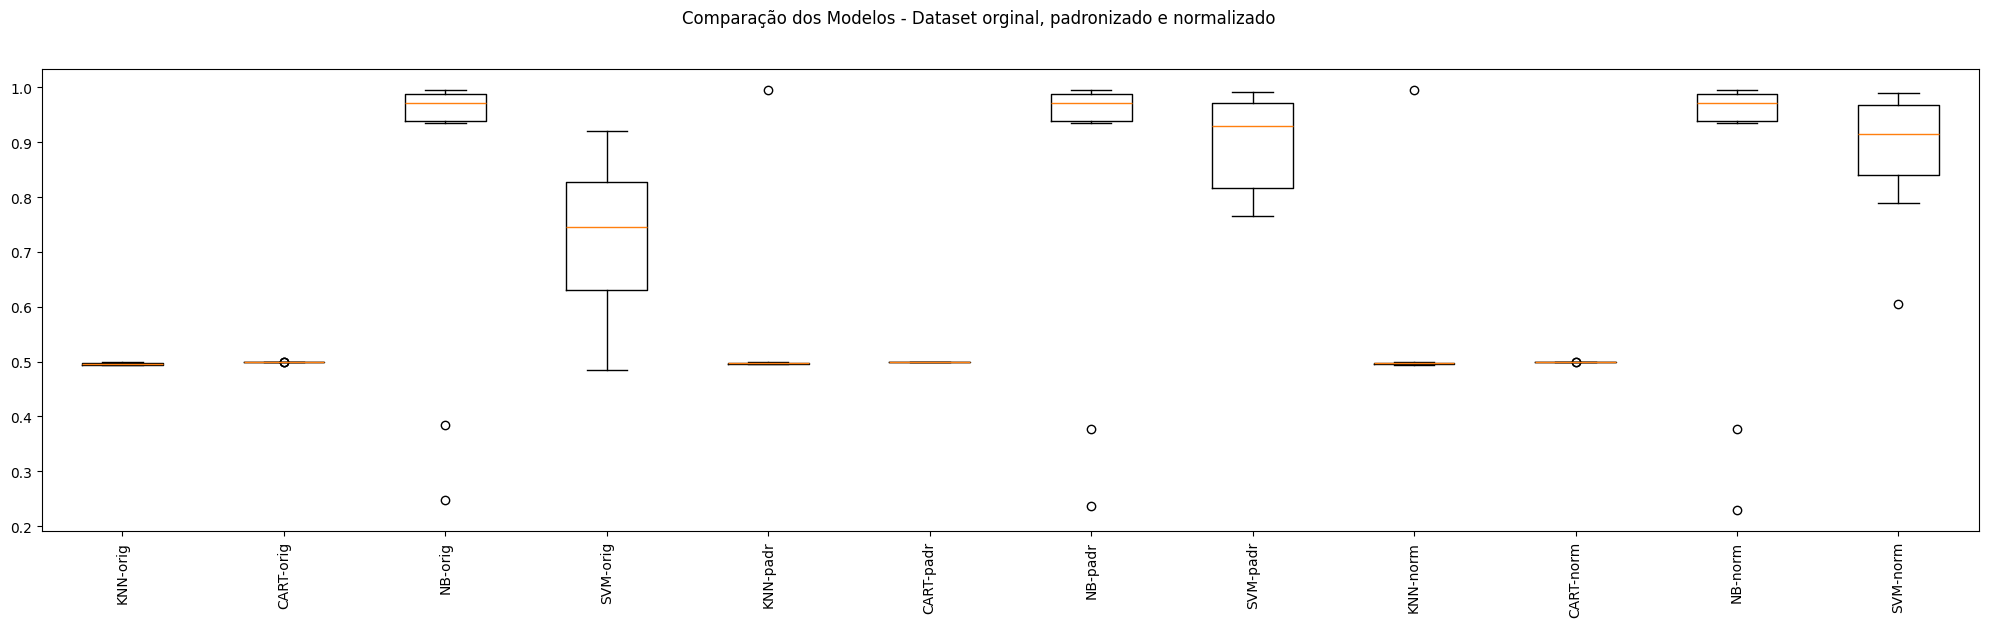

In [9]:
np.random.seed(7)

pipelines = []
results = []
names = []

knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())

dataset_select["purchase"].value_counts(normalize=True)
dataset_select.corr(numeric_only=True)["purchase"].sort_values(ascending=False)

numeric_transformer_standard = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

numeric_transformer_minmax = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_original = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="mean"), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols)
    ]
)

preprocessor_standard = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_standard, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_minmax, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

standard_scaler = ('StandartScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

pipelines.append((
    "KNN-orig",
    Pipeline([
        ("preprocessor", preprocessor_original),
        ("model", KNeighborsClassifier())
    ])
))

pipelines.append((
    "CART-orig",
    Pipeline([
        ("preprocessor", preprocessor_original),
        ("model", DecisionTreeClassifier())
    ])
))

pipelines.append((
    "NB-orig",
    Pipeline([
        ("preprocessor", preprocessor_original),
        ("model", GaussianNB())
    ])
))

pipelines.append((
    "SVM-orig",
    Pipeline([
        ("preprocessor", preprocessor_original),
        ("model", SVC(probability=True, random_state=seed))
    ])
))

pipelines.append((
    "KNN-padr",
    Pipeline([
        ("preprocessor", preprocessor_standard),
        ("model", KNeighborsClassifier())
    ])
))

pipelines.append((
    "CART-padr",
    Pipeline([
        ("preprocessor", preprocessor_standard),
        ("model", DecisionTreeClassifier())
    ])
))

pipelines.append((
    "NB-padr",
    Pipeline([
        ("preprocessor", preprocessor_standard),
        ("model", GaussianNB())
    ])
))

pipelines.append((
    "SVM-padr",
    Pipeline([
        ("preprocessor", preprocessor_standard),
        ("model", SVC(probability=True, random_state=seed))
    ])
))

pipelines.append((
    "KNN-norm",
    Pipeline([
        ("preprocessor", preprocessor_minmax),
        ("model", KNeighborsClassifier())
    ])
))

pipelines.append((
    "CART-norm",
    Pipeline([
        ("preprocessor", preprocessor_minmax),
        ("model", DecisionTreeClassifier())
    ])
))

pipelines.append((
    "NB-norm",
    Pipeline([
        ("preprocessor", preprocessor_minmax),
        ("model", GaussianNB())
    ])
))

pipelines.append((
    "SVM-norm",
    Pipeline([
        ("preprocessor", preprocessor_minmax),
        ("model", SVC(probability=True, random_state=seed))
    ])
))
for name, model in pipelines:
    cv_results = cross_val_score(model,
                                 X_train,
                                 Y_train,
                                 cv=kfold,
                                 scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = f"{name}: {cv_results.mean():.3f} ({cv_results.std():.3f})" # formatando para 3 casas decimais
    print(msg)

fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

# Observação a respeito da criação e avaliação de modelos

Devido à presença de variáveis categóricas e valores ausentes no dataset, foi necessário substituir a abordagem tradicional de escalonamento isolado por pipelines completos contendo imputação, codificação One-Hot e escalonamento. Para avaliar o impacto da padronização e da normalização no desempenho dos algoritmos, foram construídos pipelines distintos utilizando StandardScaler e MinMaxScaler, integrados a um ColumnTransformer.

Quando avaliado com métricas apropriadas para dados desbalanceados (ROC AUC), observa-se que modelos treinados sem pré-processamento apresentam desempenho equivalente ao acaso. A aplicação de pipelines contendo imputação, codificação e normalização é essencial para o aprendizado efetivo. O modelo SVM apresentou o melhor desempenho e maior estabilidade, sendo selecionado como modelo final.

# Uso do DummyClassifier para validar acurácia

Nos estudo realizados junto com o dataset, considerando que existiam correções que faziam a aprendizagem estar com uma acurácia não válida, utilizei o DummyClassifier para provar que o método utilizado estaria sendo eficaz, se o modelo gerado utilizando um dummy classifier fosse maior que 0.95, isso apontaria que o modelo gerado não seria melhor que um modelo burro e precisa ser revisado.

In [10]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
cross_val_score(dummy, X_train, Y_train, cv=kfold, scoring="roc_auc").mean()

np.float64(0.5)

# Observação do resultado do DummyClassifier utilizando scoring="roc_auc"

Ao utilizar o scoring="roc_auc" foi possível apresentar uma diferença substancial entre os modelos gerados através das pipelines. Anteriormente utilizando o scoring="accuracy" houve um apontamento claro de erro, no caso apresentando um resultado igual ~0.998, o que demonstra claramente uma máscara sobre o problema, que indicou a necessidade de troca do scoring.

In [11]:
from sklearn.metrics import classification_report
model.fit(X_train, Y_train)
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob >=0.95).astype(int)
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       1.00      1.00      1.00      1565

    accuracy                           1.00      1568
   macro avg       0.50      0.50      0.50      1568
weighted avg       1.00      1.00      1.00      1568



# Otimização dos hiperparâmetros

In [12]:
np.random.seed(7)

results = {}
best_grids = {}

param_grids = {
    "KNN": {
        "model__n_neighbors": [3,5,7,9,11,15,21],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },
    "CART": {
        "model__max_depth": [None, 3, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5]
    },
    "NB": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    },
    "SVM": {
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__kernel": ["rbf"]
    }
}

pipeline_grids = {
    "KNN": pipeline_knn,
    "CART": pipeline_cart,
    "NB": pipeline_nb,
    "SVM": pipeline_svm
}

for model_name in pipeline_grids.keys():
  print(f"\n Otimizando {model_name} -->")

  grid = GridSearchCV(
      estimator=pipeline_grids[model_name],
      param_grid=param_grids[model_name],
      scoring="roc_auc",
      cv=kfold,
      n_jobs=-1
  )

  grid.fit(X_train, Y_train)

  # Armazenando os melhores grids
  best_grids[model_name] = grid

  results[model_name] = {
      "best_score": grid.best_score_,
      "best_params": grid.best_params_,
      "best_estimator": grid.best_estimator_
  }

  print(f"Melhor ROC_AUC: {grid.best_score_: .4f}")
  print(f"Melhores parâmetros: {grid.best_params_}")

best_model_name = max(results, key=lambda x: results[x]["best_score"])
print("\n=== DECISÃO FINAL DE MODELO ===\n")
print("Melhor modelo:", best_model_name)
print("ROC_AUC:", results[best_model_name]["best_score"])


 Otimizando KNN -->
Melhor ROC_AUC:  0.6411
Melhores parâmetros: {'model__metric': 'euclidean', 'model__n_neighbors': 15, 'model__weights': 'uniform'}

 Otimizando CART -->
Melhor ROC_AUC:  0.7583
Melhores parâmetros: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

 Otimizando NB -->
Melhor ROC_AUC:  0.8421
Melhores parâmetros: {'model__var_smoothing': 1e-06}

 Otimizando SVM -->
Melhor ROC_AUC:  0.9475
Melhores parâmetros: {'model__C': 100, 'model__gamma': 0.1, 'model__kernel': 'rbf'}

=== DECISÃO FINAL DE MODELO ===

Melhor modelo: SVM
ROC_AUC: 0.9474530066088833


# Observação a respeito da otimização de híperparâmetros

Já havia sido decidido anteriormente que o SVM seria o modelo vencedor, e isso se confirma através da otimização dos hiperparâmetros que leva o modelo SVM a ser o modelo com melhor resultado para esse projeto.

As demais otimizações foram utilizadas apenas para fins de comparação e de forma didática, com intuito de explorar a capacidade de otimização de cada modelo.

Através desse modelo (SVM) se é capaz de criar um modelo preditivo de probabilidade de compra baseado nos parâmetros apresentados.

# Finalização do Modelo

In [13]:
# Agora será feita a finalização do modelo

#grid_svm é o GridSearchCV já treinado
grid_svm = best_grids["SVM"]

final_model = grid_svm.best_estimator_

print("Melhor modelo selecionado: SVM")
print("Melhores hiperparâmetros:")
print(grid_svm.best_params_)
print(f"Melhor ROC_AUC (Validação Cruzada): {grid_svm.best_score_:.4f}")

# Probabilidades (classe positiva = compra)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(Y_test, y_test_proba)
print(f"\nROC_AUC no conjunto de teste: {roc_auc_test:.4f}")

y_test_pred = final_model.predict(X_test)

print("\nRelatório de Classificação:")
print(classification_report(Y_test, y_test_pred))

final_model.fit(X, Y)

# Por fim, será salvo o modelo
joblib.dump(final_model, "modelo_final_ecommerce.pkl")

print("="*70)
print("MODELO FINAL GERADO --> Nome do modelo: modelo_final_ecommerce.pkl")
print("="*70)

Melhor modelo selecionado: SVM
Melhores hiperparâmetros:
{'model__C': 100, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Melhor ROC_AUC (Validação Cruzada): 0.9475

ROC_AUC no conjunto de teste: 0.9059

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       1.00      1.00      1.00      1565

    accuracy                           1.00      1568
   macro avg       0.50      0.50      0.50      1568
weighted avg       1.00      1.00      1.00      1568

MODELO FINAL GERADO --> Nome do modelo: modelo_final_ecommerce.pkl


# Relatório final

Após a comparação de múltiplos algoritmos, o modelo SVM apresentou o melhor desempenho segundo a métrica ROC_AUC. Seus hiperparâmetros foram otimizados via GridSearchCV com validação cruzada estratificada. O modelo final foi então re-treinado com todo o conjunto de dados e serializado para uso na aplicação full stack.